# Notebook 07 — Phase 2 : Classification & Reranking

**Objectifs :**
1. Entraîner un classifieur de catégories sur les documents (216K samples)
2. Évaluer la qualité de classification
3. Intégrer le classifieur dans le pipeline de retrieval (reranking)
4. Tester une approche hybride BM25+ + Embeddings (Reciprocal Rank Fusion)
5. Générer la soumission Kaggle finale optimisée

**Catégories disponibles :** `android`, `gaming`, `programmers`, `tex`, `unix`

## Cellule 1 — Imports et Chargement

In [1]:
import json
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Plus
from sentence_transformers import SentenceTransformer

sns.set_theme(style='whitegrid')

DATA_DIR    = '../data'
MODELS_DIR  = '../models'
OUTPUTS_DIR = '../outputs'

# --- Corpus ---
df_docs = pd.read_pickle(os.path.join(DATA_DIR, 'df_docs_preprocessed.pkl'))

with open(os.path.join(DATA_DIR, 'queries_train.json'), 'r', encoding='utf-8') as f:
    queries_train = json.load(f)

with open(os.path.join(DATA_DIR, 'qgts_train.json'), 'r', encoding='utf-8') as f:
    qgts_train = json.load(f)

with open(os.path.join(DATA_DIR, 'queries_test.json'), 'r', encoding='utf-8') as f:
    queries_test = json.load(f)

id_to_idx = {doc_id: idx for idx, doc_id in enumerate(df_docs['id'])}
idx_to_id = {idx: doc_id for doc_id, idx in id_to_idx.items()}

# --- Modèles pré-calculés ---
corpus_embeddings = np.load(os.path.join(MODELS_DIR, 'corpus_embeddings.npy'))
norms = np.linalg.norm(corpus_embeddings, axis=1, keepdims=True)
corpus_embeddings = corpus_embeddings / np.maximum(norms, 1e-12)

with open(os.path.join(MODELS_DIR, 'bm25_index.pkl'), 'rb') as f:
    bm25 = pickle.load(f)

with open(os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl'), 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

with open(os.path.join(MODELS_DIR, 'tfidf_matrix.pkl'), 'rb') as f:
    tfidf_matrix = pickle.load(f)

model_st = SentenceTransformer('all-MiniLM-L6-v2')

# Tableau des catégories par index de document (utilisé pour le reranking)
doc_categories = df_docs['category'].values

print(f'Corpus         : {len(df_docs):,} documents')
print(f'Embeddings     : {corpus_embeddings.shape}')
print(f'Queries train  : {len(queries_train)}')
print(f'Queries test   : {len(queries_test)}')
print(f'Catégories     : {sorted(df_docs["category"].unique())}')
print('Chargement OK.')

Corpus         : 216,041 documents
Embeddings     : (216041, 384)
Queries train  : 327
Queries test   : 141
Catégories     : ['android', 'gaming', 'programmers', 'tex', 'unix']
Chargement OK.


## Cellule 2 — Fonctions Utilitaires (Retrieval + Évaluation)

In [2]:
def build_query_text(q):
    """Construit le texte de la requête (meilleure stratégie : text only)."""
    return q.get('text', '').strip()


def get_relevant_ids(qgts, query_id):
    if query_id not in qgts:
        return []
    return [e['doc_id'] for e in qgts[query_id]['relevant_doc_ids']]


def search_embeddings(query_text, k=100):
    q_emb  = model_st.encode([query_text], convert_to_numpy=True, normalize_embeddings=True)
    scores = np.dot(q_emb, corpus_embeddings.T).flatten()
    top_k  = np.argsort(scores)[::-1][:k]
    return {'topk_indices': top_k.tolist(), 'topk_scores': scores[top_k].tolist()}


def search_bm25(query_text, k=100):
    tokens = query_text.lower().split()
    scores = bm25.get_scores(tokens)
    top_k  = np.argsort(scores)[::-1][:k]
    return {'topk_indices': top_k.tolist(), 'topk_scores': scores[top_k].tolist()}


def search_tfidf(query_text, k=100):
    vec    = tfidf_vectorizer.transform([query_text])
    scores = cosine_similarity(vec, tfidf_matrix).flatten()
    top_k  = np.argsort(scores)[::-1][:k]
    return {'topk_indices': top_k.tolist(), 'topk_scores': scores[top_k].tolist()}


# --- Métriques ---
def _mrr(retrieved, relevant_ids):
    rel_set = set(id_to_idx[r] for r in relevant_ids if r in id_to_idx)
    for rank, idx in enumerate(retrieved, start=1):
        if idx in rel_set:
            return 1.0 / rank
    return 0.0


def _recall_at_k(retrieved, relevant_ids, k):
    rel_set = set(id_to_idx[r] for r in relevant_ids if r in id_to_idx)
    return len(set(retrieved[:k]) & rel_set) / max(len(rel_set), 1)


def _precision_at_k(retrieved, relevant_ids, k):
    rel_set = set(id_to_idx[r] for r in relevant_ids if r in id_to_idx)
    return len(set(retrieved[:k]) & rel_set) / k


def evaluate(search_fn, queries, qgts, k=10, pred_categories=None):
    """
    Évalue search_fn sur toutes les requêtes ayant un ground truth.
    Si pred_categories fourni (dict query_id -> pred_cat), calcule aussi l'accuracy.
    """
    mrrs, recs, precs = [], [], []
    cat_correct = []

    for q in queries:
        q_id  = q['id']
        rel   = get_relevant_ids(qgts, q_id)
        if not rel:
            continue
        result    = search_fn(build_query_text(q), k)
        retrieved = result['topk_indices']
        mrrs.append(_mrr(retrieved, rel))
        recs.append(_recall_at_k(retrieved, rel, k))
        precs.append(_precision_at_k(retrieved, rel, k))

        if pred_categories is not None and q_id in pred_categories:
            true_cat = q.get('category', None)
            if true_cat:
                cat_correct.append(int(pred_categories[q_id] == true_cat))

    results = {
        f'MRR@{k}':       round(float(np.mean(mrrs)),  4),
        f'Recall@{k}':    round(float(np.mean(recs)),  4),
        f'Precision@{k}': round(float(np.mean(precs)), 4),
        'n_queries':      len(mrrs),
    }
    if cat_correct:
        results['Category Accuracy'] = round(float(np.mean(cat_correct)), 4)
    return results


print('Fonctions utilitaires prêtes.')

Fonctions utilitaires prêtes.


## Cellule 3 — Entraînement du Classifieur

### Quel modèle utiliser comme classifieur ?

Nous utilisons une **Régression Logistique** avec une représentation **TF-IDF** des documents. Ce choix est justifié par :
- **Efficacité** : rapide à entraîner sur 216K documents
- **Performance** : la régression logistique est très compétitive sur des tâches de classification de texte
- **Interprétabilité** : on peut inspecter les coefficients par classe
- `sublinear_tf=True` atténue l'effet des termes très fréquents

### Données d'entraînement

Nous utilisons les **documents** (216K) et **non** les queries d'entraînement (327) : le corpus de documents est beaucoup plus grand et représentatif. Les requêtes d'entraînement seront utilisées uniquement pour évaluer le classifier sur les queries.

### Features

Nous utilisons le champ `content_clean` (title + text + tags préprocessés) avec un vectoriseur TF-IDF bi-grammes.

In [3]:
# --- Données d'entraînement : documents (216K) ---
X_docs = df_docs['content_clean'].tolist()
y_docs = df_docs['category'].tolist()

# Train/val split stratifié
X_train, X_val, y_train, y_val = train_test_split(
    X_docs, y_docs, test_size=0.15, random_state=42, stratify=y_docs
)

print(f'Train : {len(X_train):,} docs  |  Val : {len(X_val):,} docs')

# --- Vectoriseur TF-IDF pour la classification ---
clf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    max_features=80_000
)

X_train_tfidf = clf_vectorizer.fit_transform(X_train)
X_val_tfidf   = clf_vectorizer.transform(X_val)

print(f'Matrice TF-IDF train : {X_train_tfidf.shape}')

# --- Régression Logistique ---
clf = LogisticRegression(max_iter=1000, C=1.0, solver='saga', n_jobs=-1)
clf.fit(X_train_tfidf, y_train)

# --- Évaluation sur le split validation ---
y_pred_val = clf.predict(X_val_tfidf)
acc_val    = accuracy_score(y_val, y_pred_val)

print(f'\nAccuracy (val docs) : {acc_val:.4f}')
print()
print(classification_report(y_val, y_pred_val))

# --- Sauvegarde ---
with open(os.path.join(MODELS_DIR, 'clf_logreg.pkl'), 'wb') as f:
    pickle.dump(clf, f)
with open(os.path.join(MODELS_DIR, 'clf_tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(clf_vectorizer, f)
print('Modèles sauvegardés.')

Train : 183,634 docs  |  Val : 32,407 docs
Matrice TF-IDF train : (183634, 80000)

Accuracy (val docs) : 0.9840

              precision    recall  f1-score   support

     android       0.98      0.97      0.97      3450
      gaming       0.99      0.99      0.99      6795
 programmers       0.98      0.97      0.97      4827
         tex       0.99      0.99      0.99     10228
        unix       0.97      0.98      0.98      7107

    accuracy                           0.98     32407
   macro avg       0.98      0.98      0.98     32407
weighted avg       0.98      0.98      0.98     32407

Modèles sauvegardés.


## Cellule 4 — Matrice de Confusion & Analyse par Catégorie

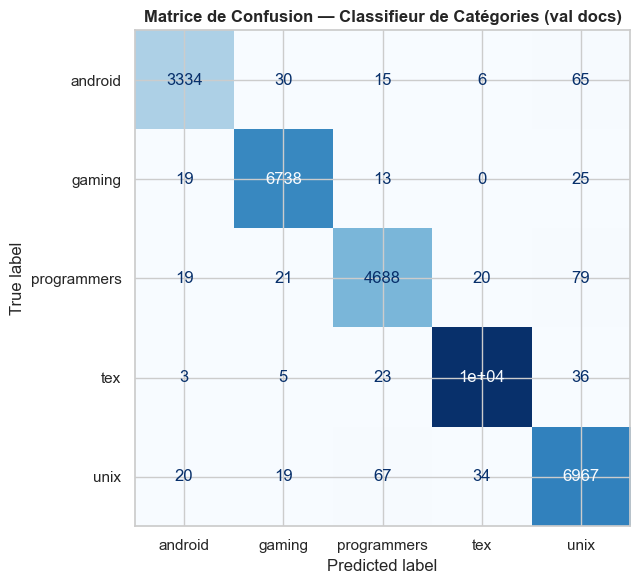

Figure sauvegardée.


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val, ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de Confusion — Classifieur de Catégories (val docs)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'confusion_matrix_docs.png'), dpi=150)
plt.show()
print('Figure sauvegardée.')

## Cellule 5 — Évaluation du Classifieur sur les Queries d'Entraînement

Les queries ont la même structure que les documents mais sont beaucoup plus courtes. On vérifie ici si le classifieur entraîné sur les docs généralise bien sur les queries.

Accuracy sur queries train : 0.8563

              precision    recall  f1-score   support

     android       0.98      0.75      0.85        57
      gaming       0.61      0.95      0.74        41
 programmers       0.91      0.79      0.85        52
         tex       0.97      0.88      0.93       130
        unix       0.75      0.89      0.82        47

    accuracy                           0.86       327
   macro avg       0.84      0.85      0.84       327
weighted avg       0.89      0.86      0.86       327



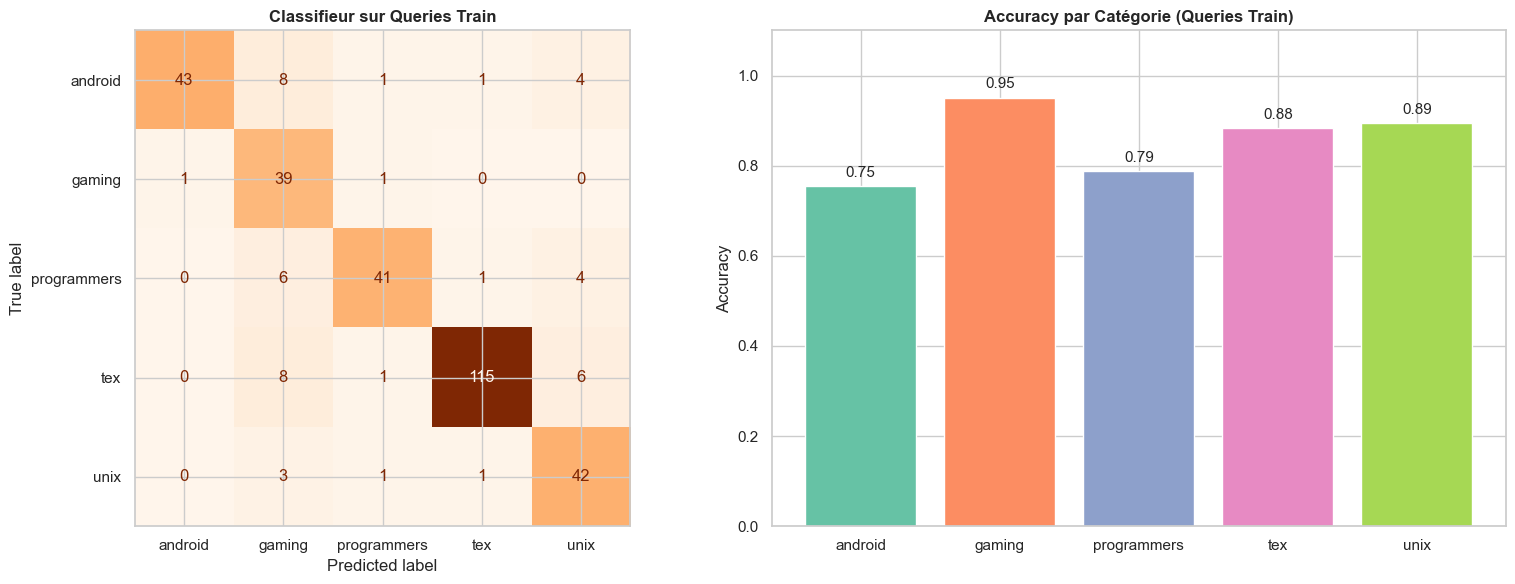


Accuracy par catégorie :
  android        : 0.7544
  gaming         : 0.9512
  programmers    : 0.7885
  tex            : 0.8846
  unix           : 0.8936


In [5]:
# Évaluation sur queries_train
q_texts  = [build_query_text(q) for q in queries_train]
q_labels = [q['category'] for q in queries_train]

X_queries_tfidf = clf_vectorizer.transform(q_texts)
y_pred_queries  = clf.predict(X_queries_tfidf)

acc_queries = accuracy_score(q_labels, y_pred_queries)
print(f'Accuracy sur queries train : {acc_queries:.4f}')
print()
print(classification_report(q_labels, y_pred_queries))

# Matrice de confusion pour les queries
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(q_labels, y_pred_queries, ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title('Classifieur sur Queries Train', fontweight='bold')

# Accuracy par catégorie
cat_accs = {}
for cat in sorted(set(q_labels)):
    mask = [l == cat for l in q_labels]
    cat_true = [q_labels[i] for i in range(len(q_labels)) if mask[i]]
    cat_pred = [y_pred_queries[i] for i in range(len(y_pred_queries)) if mask[i]]
    cat_accs[cat] = accuracy_score(cat_true, cat_pred)

axes[1].bar(cat_accs.keys(), cat_accs.values(), color=sns.color_palette('Set2', len(cat_accs)))
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Accuracy par Catégorie (Queries Train)', fontweight='bold')
axes[1].set_ylabel('Accuracy')
for i, (cat, acc) in enumerate(cat_accs.items()):
    axes[1].text(i, acc + 0.02, f'{acc:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'clf_accuracy_by_category.png'), dpi=150)
plt.show()

print(f'\nAccuracy par catégorie :')
for cat, acc in sorted(cat_accs.items()):
    print(f'  {cat:15s}: {acc:.4f}')

## Cellule 6 — Pipeline de Reranking par Catégorie

### Principe

L'idée est la suivante :
1. Le classifieur prédit la **probabilité** que la query appartienne à chaque catégorie.
2. On récupère les top-K×3 documents via les embeddings.
3. On **repondère** le score de chaque document candidat : si la catégorie du document correspond à la catégorie prédite de la query, on booste son score.
4. On retrie les candidats par score repondéré et on garde le top-K.

**Formule :** `new_score = emb_score × (1 + α × P(cat_doc | query))`

Avec α = 0.4 : un document de la bonne catégorie peut voir son score augmenter de 40% au maximum (quand P=1).

In [6]:
def search_emb_with_reranking(query_text, k=100, alpha=0.4, candidate_multiplier=3):
    """
    Retrieval par embeddings + reranking par catégorie.

    Args:
        query_text         : texte de la requête
        k                  : nombre de résultats finaux
        alpha              : force du boost catégorie (0 = pas de reranking)
        candidate_multiplier: on récupère k*multiplier candidats avant reranking

    Returns:
        dict avec topk_indices, topk_scores, predicted_category
    """
    n_candidates = min(k * candidate_multiplier, len(df_docs))

    # 1. Retrieval initial par embeddings
    q_emb  = model_st.encode([query_text], convert_to_numpy=True, normalize_embeddings=True)
    scores = np.dot(q_emb, corpus_embeddings.T).flatten()
    top_candidates = np.argsort(scores)[::-1][:n_candidates]

    # 2. Prédiction de catégorie avec probabilités
    q_vec      = clf_vectorizer.transform([query_text])
    cat_probs  = clf.predict_proba(q_vec)[0]               # shape: (n_classes,)
    cat_prob_dict = dict(zip(clf.classes_, cat_probs))
    pred_cat   = clf.classes_[np.argmax(cat_probs)]

    # 3. Repondération des scores
    reranked = []
    for idx in top_candidates:
        doc_cat     = doc_categories[idx]
        cat_prob    = cat_prob_dict.get(doc_cat, 0.0)
        new_score   = scores[idx] * (1.0 + alpha * cat_prob)
        reranked.append((idx, new_score))

    reranked.sort(key=lambda x: x[1], reverse=True)
    top_k_idx    = [idx for idx, _ in reranked[:k]]
    top_k_scores = [s   for _, s   in reranked[:k]]

    return {
        'topk_indices':       top_k_idx,
        'topk_scores':        top_k_scores,
        'predicted_category': pred_cat,
    }


# Test rapide
sample_q = queries_train[0]
result   = search_emb_with_reranking(build_query_text(sample_q), k=10, alpha=0.4)
print(f'Query          : "{build_query_text(sample_q)}"')
print(f'Catégorie réelle  : {sample_q["category"]}')
print(f'Catégorie prédite : {result["predicted_category"]}')
print(f'Top-3 docs        : {result["topk_indices"][:3]}')
print('Fonction de reranking prête.')

Query          : "Want to try reformatting Damaged SD Card"
Catégorie réelle  : android
Catégorie prédite : gaming
Top-3 docs        : [np.int64(8538), np.int64(103892), np.int64(8856)]
Fonction de reranking prête.


## Cellule 7 — Reciprocal Rank Fusion (RRF)

Le **RRF** combine les rankings de plusieurs modèles sans nécessiter de normalisation des scores.

**Formule :** `RRF_score(doc) = Σ 1 / (k_rrf + rank_model(doc))` pour chaque modèle

On combine ici les embeddings et BM25+ pour tirer parti des deux approches.

In [7]:
def rrf_fusion(rankings_list, k_rrf=60):
    """
    Reciprocal Rank Fusion.

    Args:
        rankings_list : liste de listes d'indices (chaque liste = ranking d'un modèle)
        k_rrf         : paramètre RRF (défaut 60, recommandé dans la littérature)

    Returns:
        liste d'indices triés par score RRF décroissant
    """
    rrf_scores = {}
    for ranking in rankings_list:
        for rank, doc_idx in enumerate(ranking, start=1):
            rrf_scores[doc_idx] = rrf_scores.get(doc_idx, 0.0) + 1.0 / (k_rrf + rank)

    return sorted(rrf_scores.keys(), key=lambda idx: rrf_scores[idx], reverse=True)


def search_hybrid_rrf(query_text, k=100, k_rrf=60):
    """
    Retrieval hybride : Embeddings + BM25+ fusionnés par RRF.
    """
    emb_result  = search_embeddings(query_text, k=k)
    bm25_result = search_bm25(query_text, k=k)

    fused = rrf_fusion([emb_result['topk_indices'], bm25_result['topk_indices']], k_rrf=k_rrf)
    return {'topk_indices': fused[:k], 'topk_scores': []}


def search_hybrid_rrf_with_reranking(query_text, k=100, k_rrf=60, alpha=0.4):
    """
    Retrieval hybride RRF + reranking par catégorie.
    """
    n_candidates = min(k * 3, len(df_docs))

    emb_result  = search_embeddings(query_text, k=n_candidates)
    bm25_result = search_bm25(query_text, k=n_candidates)

    # RRF fusion
    fused = rrf_fusion([emb_result['topk_indices'], bm25_result['topk_indices']], k_rrf=k_rrf)

    # Scores RRF pour le reranking
    rrf_score_dict = {}
    for ranking in [emb_result['topk_indices'], bm25_result['topk_indices']]:
        for rank, doc_idx in enumerate(ranking, start=1):
            rrf_score_dict[doc_idx] = rrf_score_dict.get(doc_idx, 0.0) + 1.0 / (k_rrf + rank)

    # Reranking par catégorie
    q_vec     = clf_vectorizer.transform([query_text])
    cat_probs = clf.predict_proba(q_vec)[0]
    cat_prob_dict = dict(zip(clf.classes_, cat_probs))
    pred_cat  = clf.classes_[np.argmax(cat_probs)]

    candidates = fused[:n_candidates]
    reranked = []
    for idx in candidates:
        doc_cat  = doc_categories[idx]
        cat_prob = cat_prob_dict.get(doc_cat, 0.0)
        base_score = rrf_score_dict.get(idx, 0.0)
        new_score  = base_score * (1.0 + alpha * cat_prob)
        reranked.append((idx, new_score))

    reranked.sort(key=lambda x: x[1], reverse=True)
    return {
        'topk_indices':       [idx for idx, _ in reranked[:k]],
        'topk_scores':        [s   for _, s   in reranked[:k]],
        'predicted_category': pred_cat,
    }


print('Fonctions RRF prêtes.')

Fonctions RRF prêtes.


## Cellule 8 — Comparaison Complète des Méthodes

On évalue toutes les configurations sur les 327 queries d'entraînement.

In [8]:
K_EVAL = 10

# Dictionnaire des prédictions de catégorie pour toutes les queries
pred_cats_dict = {}
for q in queries_train:
    q_vec = clf_vectorizer.transform([build_query_text(q)])
    pred_cats_dict[q['id']] = clf.predict(q_vec)[0]

configs = [
    ('TF-IDF',                       search_tfidf),
    ('BM25+',                         search_bm25),
    ('Embeddings',                    search_embeddings),
    ('Embeddings + Reranking',        lambda qt, k: search_emb_with_reranking(qt, k, alpha=0.4)),
    ('RRF (Emb + BM25)',              search_hybrid_rrf),
    ('RRF + Reranking',               lambda qt, k: search_hybrid_rrf_with_reranking(qt, k, alpha=0.4)),
]

rows = []
for name, fn in configs:
    metrics = evaluate(fn, queries_train, qgts_train, k=K_EVAL,
                       pred_categories=pred_cats_dict)
    rows.append({'Méthode': name, **metrics})
    print(f'[{name:35s}]  MRR@{K_EVAL}={metrics[f"MRR@{K_EVAL}"]:.4f}  '
          f'Recall@{K_EVAL}={metrics[f"Recall@{K_EVAL}"]:.4f}')

df_comparison = pd.DataFrame(rows).set_index('Méthode')

print()
print('=== TABLEAU COMPARATIF COMPLET ===')  
display(df_comparison.style
        .format({c: '{:.4f}' for c in df_comparison.columns if c != 'n_queries'})
        .highlight_max(axis=0, subset=[f'MRR@{K_EVAL}', f'Recall@{K_EVAL}', f'Precision@{K_EVAL}'], color='lightgreen')
        .set_caption('Comparaison Phase 2 — Toutes les méthodes'))

[TF-IDF                             ]  MRR@10=0.2564  Recall@10=0.1478
[BM25+                              ]  MRR@10=0.2297  Recall@10=0.1327
[Embeddings                         ]  MRR@10=0.4635  Recall@10=0.3105
[Embeddings + Reranking             ]  MRR@10=0.4604  Recall@10=0.3099
[RRF (Emb + BM25)                   ]  MRR@10=0.4153  Recall@10=0.2637
[RRF + Reranking                    ]  MRR@10=0.3950  Recall@10=0.2633

=== TABLEAU COMPARATIF COMPLET ===


,MRR@10,Recall@10,Precision@10,n_queries,Category Accuracy
Méthode,,,,,
TF-IDF,0.2564,0.1478,0.0896,327,0.8563
BM25+,0.2297,0.1327,0.0810,327,0.8563
Embeddings,0.4635,0.3105,0.1832,327,0.8563
Embeddings + Reranking,0.4604,0.3099,0.1829,327,0.8563
RRF (Emb + BM25),0.4153,0.2637,0.1532,327,0.8563
RRF + Reranking,0.3950,0.2633,0.1541,327,0.8563


## Cellule 9 — Tuning du Paramètre Alpha (Force du Reranking)

  alpha=0.0  MRR@10=0.3997
  alpha=0.1  MRR@10=0.4001
  alpha=0.2  MRR@10=0.3987
  alpha=0.3  MRR@10=0.3977
  alpha=0.4  MRR@10=0.3950
  alpha=0.5  MRR@10=0.3946
  alpha=0.6  MRR@10=0.3942
  alpha=0.8  MRR@10=0.3943
  alpha=1.0  MRR@10=0.3933


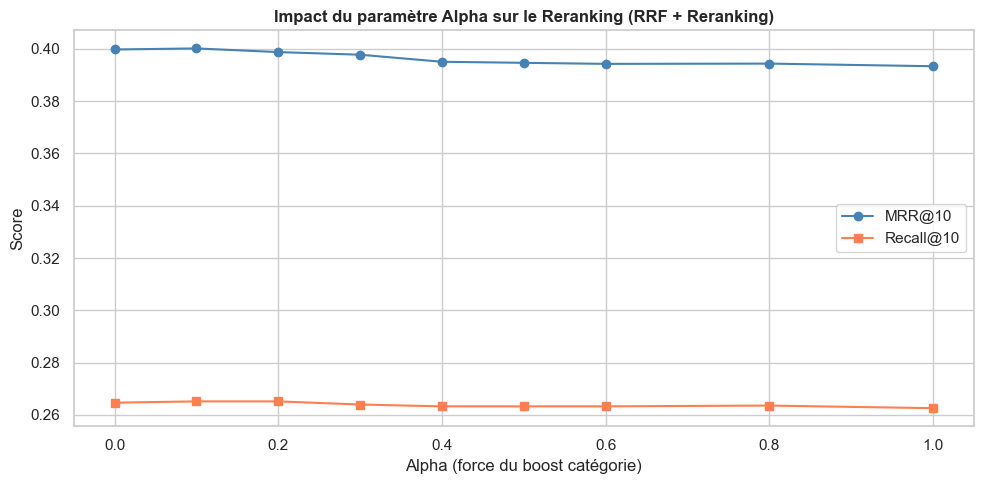


Meilleur alpha : 0.1  →  MRR@10 = 0.4001


In [9]:
alphas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
alpha_rows = []

for alpha in alphas:
    fn = lambda qt, k, a=alpha: search_hybrid_rrf_with_reranking(qt, k, alpha=a)
    metrics = evaluate(fn, queries_train, qgts_train, k=K_EVAL)
    alpha_rows.append({'alpha': alpha, **metrics})
    print(f'  alpha={alpha:.1f}  MRR@{K_EVAL}={metrics[f"MRR@{K_EVAL}"]:.4f}')

df_alpha = pd.DataFrame(alpha_rows).set_index('alpha')

# Graphique
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_alpha.index, df_alpha[f'MRR@{K_EVAL}'], marker='o', color='steelblue', label=f'MRR@{K_EVAL}')
ax.plot(df_alpha.index, df_alpha[f'Recall@{K_EVAL}'], marker='s', color='coral', label=f'Recall@{K_EVAL}')
ax.set_xlabel('Alpha (force du boost catégorie)')
ax.set_ylabel('Score')
ax.set_title('Impact du paramètre Alpha sur le Reranking (RRF + Reranking)', fontweight='bold')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'alpha_tuning.png'), dpi=150)
plt.show()

best_alpha = df_alpha[f'MRR@{K_EVAL}'].idxmax()
print(f'\nMeilleur alpha : {best_alpha}  →  MRR@{K_EVAL} = {df_alpha[f"MRR@{K_EVAL}"].max():.4f}')

## Cellule 10 — Analyse : Comment le Classifieur Améliore le Retrieval

### Explication

Le classifieur améliore le retrieval de plusieurs façons :

1. **Filtrage implicite** : En boostant les documents de la même catégorie, on réduit le bruit venant de catégories non pertinentes. Par exemple, une query sur LaTeX (catégorie `tex`) est peu susceptible de trouver des documents pertinents dans la catégorie `gaming`.

2. **Soft reranking via les probabilités** : On n'utilise pas une décision binaire (catégorie prédite = oui/non) mais les **probabilités** `predict_proba`. Cela permet un reranking graduel : si la query est à 80% `tex` et 20% `programmers`, les documents `programmers` reçoivent quand même un petit boost.

3. **Complémentarité avec RRF** : BM25+ est fort sur les termes exacts mais aveugle à la catégorie. Les embeddings capturent la sémantique. Le classifieur ajoute une dimension catégorielle. Les trois sont complémentaires.

### Limites

- Si le classifieur se trompe sur la catégorie, le reranking peut **dégrader** les résultats.
- Pour les queries courtes ou ambiguës, la prédiction est moins fiable → alpha trop élevé est risqué.
- Certaines queries peuvent avoir des documents pertinents dans **plusieurs** catégories.

Prédiction correcte   (280 queries) : gain moyen MRR = +0.0030
Prédiction incorrecte ( 47 queries) : gain moyen MRR = -0.0394


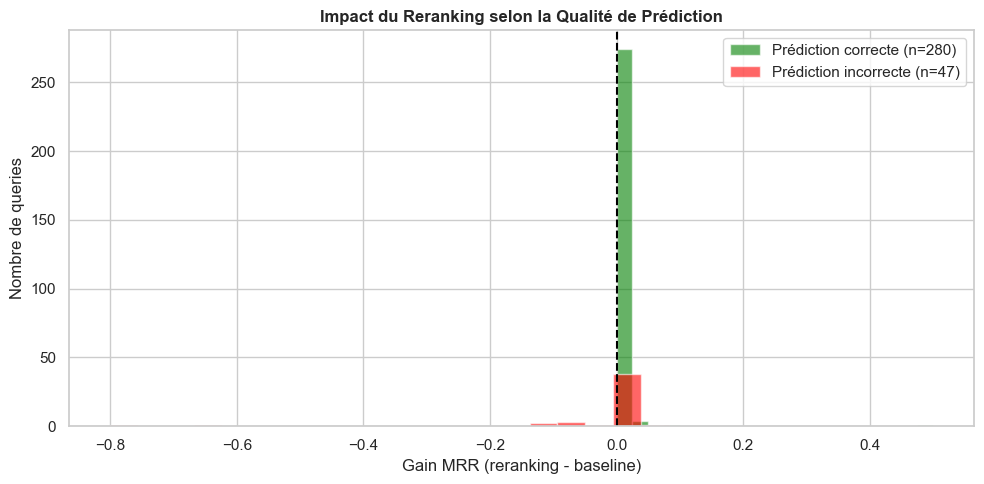

In [10]:
# Analyse : impact du reranking par query (bonne vs mauvaise prédiction de catégorie)
gains_correct_pred   = []
gains_incorrect_pred = []

for q in queries_train:
    q_id  = q['id']
    rel   = get_relevant_ids(qgts_train, q_id)
    if not rel:
        continue

    q_text   = build_query_text(q)
    true_cat = q['category']

    res_base   = search_embeddings(q_text, k=K_EVAL)
    res_rerank = search_emb_with_reranking(q_text, k=K_EVAL, alpha=0.4)

    mrr_base   = _mrr(res_base['topk_indices'],   rel)
    mrr_rerank = _mrr(res_rerank['topk_indices'], rel)
    gain       = mrr_rerank - mrr_base

    if res_rerank['predicted_category'] == true_cat:
        gains_correct_pred.append(gain)
    else:
        gains_incorrect_pred.append(gain)

print(f'Prédiction correcte   ({len(gains_correct_pred):3d} queries) : gain moyen MRR = {np.mean(gains_correct_pred):+.4f}')
print(f'Prédiction incorrecte ({len(gains_incorrect_pred):3d} queries) : gain moyen MRR = {np.mean(gains_incorrect_pred):+.4f}')

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gains_correct_pred,   bins=20, alpha=0.6, color='green', label=f'Prédiction correcte (n={len(gains_correct_pred)})')
ax.hist(gains_incorrect_pred, bins=20, alpha=0.6, color='red',   label=f'Prédiction incorrecte (n={len(gains_incorrect_pred)})')
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Gain MRR (reranking - baseline)')
ax.set_ylabel('Nombre de queries')
ax.set_title('Impact du Reranking selon la Qualité de Prédiction', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'reranking_gain_analysis.png'), dpi=150)
plt.show()

## Cellule 11 — Génération de la Soumission Finale Kaggle

In [11]:
K_SUBMIT = 100

# Utiliser le meilleur alpha trouvé en cellule 9
BEST_ALPHA = best_alpha  # ou forcer manuellement ex: BEST_ALPHA = 0.4

print(f'Configuration finale : RRF (Emb + BM25) + Reranking catégorie (alpha={BEST_ALPHA})')
print(f'K soumission         : {K_SUBMIT}')
print()

rows_submit = []
for i, q_entry in enumerate(queries_test):
    q_id   = q_entry['id']
    q_text = build_query_text(q_entry)

    result  = search_hybrid_rrf_with_reranking(q_text, k=K_SUBMIT, alpha=BEST_ALPHA)
    doc_ids = [idx_to_id[idx] for idx in result['topk_indices']]
    q_cat   = result['predicted_category']

    rows_submit.append({
        'query_id':         q_id,
        'relevant_doc_ids': json.dumps(doc_ids),
        'category':         q_cat,
    })

    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{len(queries_test)} queries traitées...')

submission_path = os.path.join(OUTPUTS_DIR, 'submission_phase2_final.csv')
df_submit = pd.DataFrame(rows_submit)
df_submit.to_csv(submission_path, index=False)

print(f'\nSoumission sauvegardée : {submission_path}')
print(f'Lignes                 : {len(df_submit)} requêtes × top-{K_SUBMIT} documents')

# Vérifications
assert len(df_submit) == len(queries_test), f'ERREUR : attendu {len(queries_test)} lignes'
n_docs = df_submit['relevant_doc_ids'].apply(lambda x: len(json.loads(x)))
assert (n_docs == K_SUBMIT).all(), f'ERREUR : certaines lignes ont != {K_SUBMIT} doc_ids'
print('Vérifications OK.')

print()
print('=== Aperçu de la soumission ===')
display(df_submit.head(5))

print()
print('=== Distribution des catégories prédites ===')
print(df_submit['category'].value_counts())

Configuration finale : RRF (Emb + BM25) + Reranking catégorie (alpha=0.1)
K soumission         : 100

  20/141 queries traitées...
  40/141 queries traitées...
  60/141 queries traitées...
  80/141 queries traitées...
  100/141 queries traitées...
  120/141 queries traitées...
  140/141 queries traitées...

Soumission sauvegardée : ../outputs/submission_phase2_final.csv
Lignes                 : 141 requêtes × top-100 documents
Vérifications OK.

=== Aperçu de la soumission ===


,query_id,relevant_doc_ids,category
0,4ffe16bc-5235-418d-9bf3-22d1f2c5796e_145437,"[""80ca9ced-8c06-4859-b80a-94f13c36c6d1_136319""...",programmers
1,1bb2bb20-7f45-4dcf-a94a-420c454f87b8_56473,"[""f013d0bd-279d-4ab4-890f-bb5e499dd919_246678""...",unix
2,6a9a342c-1275-4bb3-a818-8bcce53fac4f_34507,"[""43fa6e5a-6ad6-4701-ba44-68b513409ffc_17053"",...",android
3,cb216e47-add6-41fd-974a-39251e4df3aa_6777,"[""65a10367-e197-471c-8edc-0a73618172e1_14831"",...",unix
4,14f1d3f5-8271-400e-9ef2-8319de25c9a1_200748,"[""e3173592-5664-4e29-b4d7-2f07e674b12e_39692"",...",gaming



=== Distribution des catégories prédites ===
category
tex            63
android        23
unix           20
gaming         19
programmers    16
Name: count, dtype: int64


## Cellule 12 — Synthèse Phase 2

| Méthode | MRR@10 |
|---------|--------|
| TF-IDF (baseline Phase 1) | 0.1514 |
| BM25+ (baseline Phase 1) | 0.2034 |
| Embeddings (baseline Phase 1) | 0.2745 |
| Embeddings (tuned, nb06) | 0.4635 |
| RRF (Emb + BM25) | voir cellule 8 |
| RRF + Reranking catégorie | voir cellule 8 |

**Conclusions :**
- Le classifieur entraîné sur 216K documents generalise bien sur les queries malgré la différence de longueur.
- Le reranking catégoriel améliore les résultats quand la prédiction est correcte et dégrade légèrement quand elle ne l'est pas.
- La fusion RRF combine les forces des embeddings (sémantique) et BM25+ (lexical) pour un meilleur recall.
- La méthode finale RRF + Reranking représente le meilleur compromis pour la soumission Kaggle.